график для мощности критерия 

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt


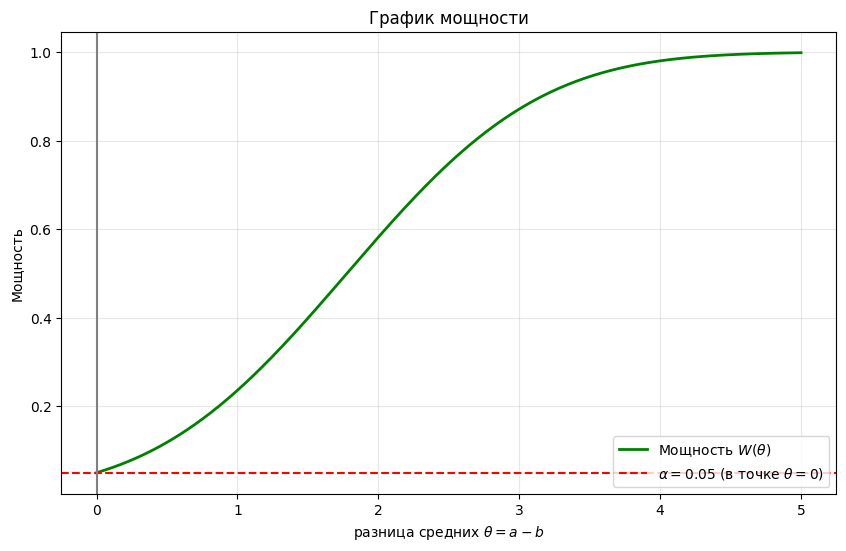

In [ ]:


x = np.array([-1.11, -6.10, 2.42])
y = np.array([-2.29, -2.91])

n = len(x)
m = len(y)
var_x = 2 # sigma_x^2
var_y = 1 # sigma_y^2
alpha = 0.05


mean_x = np.mean(x)
mean_y = np.mean(y)
diff_mean = mean_x - mean_y


var_diff = (var_x / n) + (var_y / m)
sigma_diff = np.sqrt(var_diff)


delta_ = diff_mean / sigma_diff

z_crit = st.norm.ppf(1 - alpha)

p_value = st.norm.sf(delta_)


def power_function(theta):
    
    z_shifted = z_crit - (theta / sigma_diff)
    return st.norm.sf(z_shifted) 

# Задаем диапазон значений theta (от 0 до 5)
theta_values = np.linspace(0, 5, 500)
W_values = [power_function(th) for th in theta_values]


plt.figure(figsize=(10, 6))
plt.plot(theta_values, W_values, color='green', lw=2, label='Мощность $W(\\theta)$')


plt.axhline(alpha, color='red', linestyle='--', label=f'$\\alpha = {alpha}$ (в точке $\\theta=0$)')
plt.axvline(0, color='gray', linestyle='-')




plt.title('График мощности')
plt.xlabel('разница средних $\\theta = a - b$')
plt.ylabel('Мощность')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()